# **01 · 7개년 통합 EDA — 단년 스냅샷의 함정에서 전체 패널로**

### **"7개년(2019~2025) 90,996명을 그냥 합치면 무엇이 왜곡되는가 — 표본 65%인 2022가 결과를 끌고 가고, 결측의 절반은 무응답이 아니라 '그 해 문항 부재'다. 순진한 통합이 만드는 편향을 먼저 노출해, 다운스트림(11·20·03)이 왜 그런 처리를 강제하는지를 데이터로 정의한다"**

> KPF 「언론 통계 분석·활용 경진대회」 · 분석 단위 = **연도(2019~2025) × 응답자(N=90,996)** · 산출 = 표본구조·결측·인구분포·핵심변수 분포 진단 + 문제정의→설계결정 매핑

> 📍 **파이프라인 위치**: 5단계 표준 흐름 中 **① 데이터 파악·문제정의** · CRISP-DM **P1(Business)·P2(Data Understanding)** · [전체 지도](README.md)

## **연구 질문 (이 노트북이 답하는 것)**

> **Q1.** 7개년을 **순진하게 통합(pool)** 하면 표본 구조는 어떻게 생겼는가 — 특정 연도(2022)가 결과를 지배하는가?
> **Q2.** 통합 패널의 **결측**은 응답자의 *무응답*인가, 아니면 *그 해에 문항이 없었던* 구조적 부재인가?
> **Q3.** 순진한 통합 통계는 어떤 **편향**(연령·디지털)을 낳고, 그래서 어떤 **설계 결정**(연도균등 가중·고정풀·측정불변)이 강제되는가?

## **목차**

| § | 내용 | 핵심 질문 | 산출 |
|:--:|------|-----------|------|
| 1 | 표본 구조 (+ DB①) | 누가 패널을 지배하나 | 연도별 N·2022 비중 |
| 2 | 순진한 통합 베이스라인 | pool하면 무엇이 왜곡되나 | 순진 vs 연도균등 Δ |
| 3 | 결측 진단 | 무응답인가 부재인가 | 연도×변수 가용성 |
| 4 | 인구 분포 | 표본은 누구인가 | 연령·연령군(가중 전/후) |
| 5 | 핵심변수 분포 (+ DB②) | 신뢰·다양성을 어떻게 읽나 | cred3·richness 분포 |
| 6 | 종합 | 문제→설계 매핑 | 후속 처리 근거 |

> 🔄 **v1 → v2 변경 이력**: v1은 `2025_언론수용자조사_데이터.sav` **단일 연도(N=6,000)** 만 읽어 "순진 베이스라인 → 진단"을 했다. v2는 같은 페다고지를 **7개년 전체 패널(N=90,996)** 로 끌어올린다 — *단년의 과적합/편향을 정확히 설명하려면 전체 데이터를 봐야 한다*는 원칙에 따라, 입력을 `health_index_panel.load_panel()`(하모나이즈 패널)로 교체하고 "단일연도 차원 확정" 대신 **"순진한 통합이 만드는 편향의 문제정의"** 로 목적을 재정의했다.
> ⚠️ 본 노트북은 **데이터 파악·문제정의(①·P1/P2)** 에 집중한다. 정제된 통합 6패널 그림은 [20-eda-overview](20-eda-overview.ipynb), 지수화는 [03-health-index](03-health-index.ipynb), 페르소나는 [04](04-personas-kmeans.ipynb)로 역할을 분리한다.

In [1]:
# === 01 · 7개년 통합 EDA — 셋업 & 패널 적재 ===
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager

def _kfont():
    """한글 폰트 우선 적용. 마이너스는 ASCII '-'(U+2212 깨짐 방지)."""
    for nm in ["Malgun Gothic", "맑은 고딕", "NanumGothic", "Gulim"]:
        try:
            font_manager.findfont(nm, fallback_to_default=False)
            plt.rcParams["font.family"] = nm
            break
        except Exception:
            continue
    plt.rcParams["axes.unicode_minus"] = False
_kfont()

def find_root() -> Path:
    p = Path.cwd().resolve()
    for cand in [p, *p.parents]:
        if (cand / "src/health_index_panel.py").exists():
            return cand
    raise FileNotFoundError("src/health_index_panel.py 를 찾지 못했습니다")

ROOT = find_root()
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))
import harmonize as hz                # 패널 스펙(SSOT): YEARS·cred 핵심3·고정풀8
import health_index_panel as hip      # 패널 로더(thin 어댑터)

# ⚠️ 패널 parquet은 gitignore → 없으면 먼저 `python src/harmonize.py`로 재생성.
panel = hip.load_panel()
YEARS = hz.YEARS
N = len(panel)
cov = panel["year"].value_counts().sort_index()

print(f"패널 적재: {N:,}행 × {panel.shape[1]}변수  (연도 {YEARS[0]}~{YEARS[-1]})")
print("연도별 응답자 수 (텍스트 막대):")
for y in YEARS:
    bar = "#" * int(round(40 * cov[y] / cov.max()))
    print(f"  {y}: {cov[y]:>6,}  {bar}")
print(f"\n2022 단일연도 비중: {100*cov[2022]/N:.1f}%  <- 통합 패널의 과반(가장 먼저 마주치는 사실)")

패널 적재: 90,996행 × 45변수  (연도 2019~2025)
연도별 응답자 수 (텍스트 막대):
  2019:  5,040  ###
  2020:  5,010  ###
  2021:  5,010  ###
  2022: 58,936  ########################################
  2023:  5,000  ###
  2024:  6,000  ####
  2025:  6,000  ####

2022 단일연도 비중: 64.8%  <- 통합 패널의 과반(가장 먼저 마주치는 사실)


## 1. 표본 구조 — 누가 7개년 패널을 지배하나

통합 패널은 연도별 표본 크기가 **극단적으로 불균형**하다. 2019~2025 대부분 5,000~6,000명인데 **2022만 58,936명** — 혼자 패널의 약 65%다(2022는 분석단위=개인 버전을 사용). 따라서 연도를 무시하고 응답자를 그냥 합쳐(pool) 평균내면, 그 평균은 사실상 **2022 한 해의 평균**에 가깝다. 이 비대칭을 먼저 시각화하고, 그것을 무력화하는 가중치(`wt_year_eq`)를 §2 이후의 기준 추정량으로 삼는다.

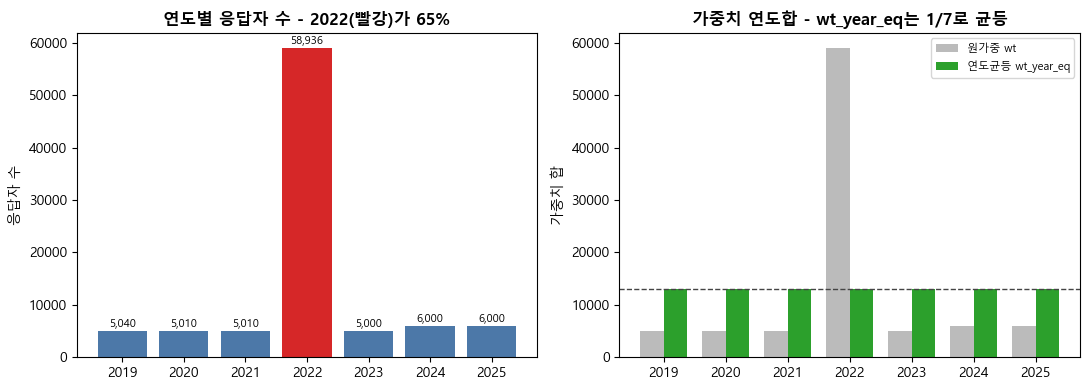

In [2]:
# [시각화 ①] 표본 구조 — 연도별 N(2022 지배) + 가중치 균등화 효과
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

colors = ["#d62728" if y == 2022 else "#4C78A8" for y in YEARS]
axes[0].bar([str(y) for y in YEARS], [cov[y] for y in YEARS], color=colors)
axes[0].set_title("연도별 응답자 수 - 2022(빨강)가 65%", weight="bold")
axes[0].set_ylabel("응답자 수")
for i, y in enumerate(YEARS):
    axes[0].text(i, cov[y] + 800, f"{cov[y]:,}", ha="center", fontsize=8)

wsum = panel.groupby("year")[["wt", "wt_year_eq"]].sum()
x = np.arange(len(YEARS)); w = 0.38
axes[1].bar(x - w/2, [wsum.loc[y, "wt"] for y in YEARS], w, label="원가중 wt", color="#bbbbbb")
axes[1].bar(x + w/2, [wsum.loc[y, "wt_year_eq"] for y in YEARS], w, label="연도균등 wt_year_eq", color="#2ca02c")
axes[1].axhline(N / len(YEARS), ls="--", color="#444", lw=1)
axes[1].set_xticks(x); axes[1].set_xticklabels([str(y) for y in YEARS])
axes[1].set_title("가중치 연도합 - wt_year_eq는 1/7로 균등", weight="bold")
axes[1].set_ylabel("가중치 합"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

> #### 🟦 Decision Box ① — 통합 집계 가중치: `wt_year_eq`(연도기여 균등)
>
> **결정**: 7개년 통합 평균·구성비는 원가중(`wt`)이 아니라 **연도기여 균등 가중(`wt_year_eq`)** 으로 집계한다. `wt_year_eq`는 각 연도가 전체에 정확히 1/7씩 기여하도록 재정규화(Σ가중 = N/T 상수)한다.
>
> **근거**: 원가중은 연도 내 모집단 대표성만 보장할 뿐, 7개년을 합치면 N이 큰 2022가 65% 비중으로 추세·평균을 끌어간다(harmonize §6). 연도균등 가중은 "2022 한 해 = 추세 전체"가 되는 표본 지배를 제거한다.
>
> **대안 기각**: ① 원가중 그대로 → 2022 편향(아래 §2에서 정량 노출). ② 2022 다운샘플 → 정보 손실·임의성. 재정규화가 무손실로 동일 효과.

#### **[발견 ①] 2022 한 해가 통합 패널의 65%를 차지한다 — "그냥 합치면 2022 조사"**

연도별 N은 2022(58,936)가 나머지 6개년 합(32,060)의 약 1.8배다. 응답자를 단순 풀링한 평균은 가중치로 보정하지 않는 한 **2022의 특성(가장 고령·가장 낮은 디지털 이용; §2·§4)을 7개년 전체의 모습으로 착각**하게 만든다. `wt_year_eq`는 연도 기여를 1/7로 균등화해 이 지배를 제거한다(오른쪽 초록 막대가 점선=N/7에 수렴).

→ **① 표본 구조 — 완료(2022 지배 확인, wt_year_eq 채택). 다음은 그 지배가 만드는 구체적 편향.**

## 2. 순진한 통합 베이스라인 — pool하면 무엇이 왜곡되나 (Before → After)

§1의 지배가 추정량에 얼마나 새는지 **정량화**한다. 같은 지표를 두 방식으로 계산해 대비한다.
- **순진 pool**: 연도 무시, 90,996명을 그냥 평균(= 2022가 65% 끌어감).
- **연도균등**: 각 연도를 `wt_year_eq`로 가중해 1/7씩 기여시킨 추정.

⚠️ 다양성 계열(매체 이용률·richness)은 **formative** 구성이라 절대수준의 연도 비교는 금지하고, 여기서는 *순진 통합이 만드는 추정 편향*만 본다(06 §결과 R4). 신뢰축(reflective)은 측정불변이 받쳐 연도 비교가 가능하다(§5·DB②).

In [3]:
# 순진한 통합(naive pool) vs 연도균등(year-equalized) 추정 대비
def yeq_mean(col: str) -> float:
    """각 연도를 wt_year_eq로 가중한 연도평균들의 단순평균(연도 기여 1/7 균등)."""
    vals = []
    for _, s in panel.groupby("year"):
        m = s[col].notna()
        if m.sum() == 0:
            continue
        vals.append(np.average(s.loc[m, col], weights=s.loc[m, "wt_year_eq"]))
    return float(np.mean(vals))

specs = [("age", "평균 연령(세)", 1.0),
         ("use_internet", "인터넷 뉴스이용 %", 100.0),
         ("use_video", "온라인동영상 %", 100.0),
         ("use_paper", "종이신문 %", 100.0)]
rows = []
for col, nm, sc in specs:
    naive = sc * panel[col].mean()
    ye = sc * yeq_mean(col)
    rows.append([nm, round(naive, 1), round(ye, 1), round(naive - ye, 1)])
tbl = pd.DataFrame(rows, columns=["지표", "순진 pool", "연도균등", "Δ(순진-균등)"])
print(tbl.to_string(index=False))
print("\n→ 순진 통합은 표본 65%인 2022(최고령·최저 디지털)로 끌려간다:")
print("   평균연령 +2.5세 과대 · 인터넷/동영상 이용률 4~5%p 과소추정.")

        지표  순진 pool  연도균등  Δ(순진-균등)
  평균 연령(세)     51.4  48.9       2.5
인터넷 뉴스이용 %     75.2  80.2      -5.0
  온라인동영상 %     20.4  24.3      -3.9
    종이신문 %      9.9   9.9       0.0

→ 순진 통합은 표본 65%인 2022(최고령·최저 디지털)로 끌려간다:
   평균연령 +2.5세 과대 · 인터넷/동영상 이용률 4~5%p 과소추정.


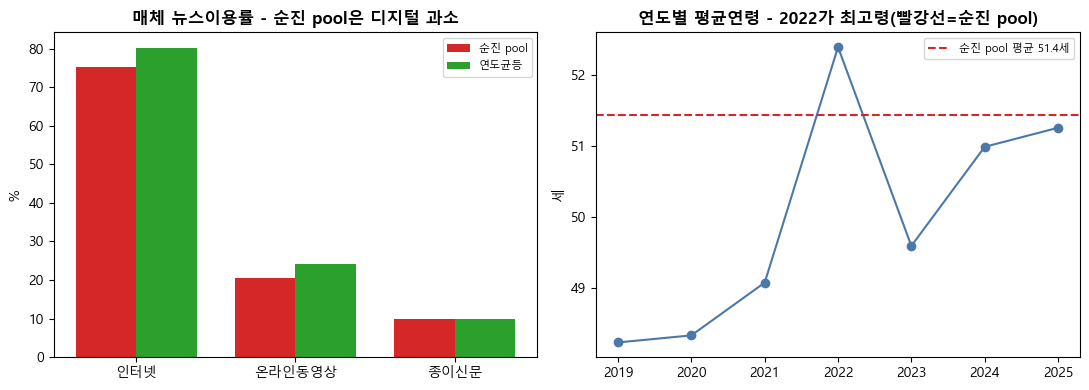

In [4]:
# [시각화 ②] 순진 pool vs 연도균등 — 디지털 이용률 과소 · 연령 과대
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

labels = ["인터넷", "온라인동영상", "종이신문"]
mcols = ["use_internet", "use_video", "use_paper"]
naive = [100 * panel[c].mean() for c in mcols]
yev = [100 * yeq_mean(c) for c in mcols]
x = np.arange(len(labels)); w = 0.38
axes[0].bar(x - w/2, naive, w, label="순진 pool", color="#d62728")
axes[0].bar(x + w/2, yev, w, label="연도균등", color="#2ca02c")
axes[0].set_xticks(x); axes[0].set_xticklabels(labels)
axes[0].set_title("매체 뉴스이용률 - 순진 pool은 디지털 과소", weight="bold")
axes[0].set_ylabel("%"); axes[0].legend(fontsize=8)

ag = panel.groupby("year")["age"].mean()
axes[1].plot([str(y) for y in YEARS], [ag[y] for y in YEARS], "o-", color="#4C78A8")
axes[1].axhline(panel["age"].mean(), ls="--", color="#d62728",
                label=f"순진 pool 평균 {panel['age'].mean():.1f}세")
axes[1].set_title("연도별 평균연령 - 2022가 최고령(빨강선=순진 pool)", weight="bold")
axes[1].set_ylabel("세"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

#### **[발견 ②] 순진 통합은 "디지털 과소·연령 과대" — 사실상 2022 조사를 보고 있다**

순진 pool 평균연령은 51.4세로 연도균등(48.9세)보다 **+2.5세 고령**으로 치우친다. 디지털 매체는 반대로 과소추정되어, 인터넷 뉴스이용은 순진 75.2% vs 연도균등 80.2%로 **-5.0%p**, 온라인동영상은 **-3.9%p** 낮게 잡힌다(종이신문은 연도 변동이 작아 Δ≈0). 모두 2022가 가장 고령·가장 낮은 디지털이면서 표본의 65%이기 때문이다 — 즉 **연도를 보정하지 않은 통합은 "2022를 7개년의 얼굴로 오인"** 한다. 이것이 `wt_year_eq`(DB①)가 해결하는 정확한 문제다.

→ **② 순진 통합 편향 — 완료(연령/디지털 정량 노출). 다음은 결측의 정체.**

## 3. 결측 진단 — 무응답인가, '그 해 문항 부재'인가

통합 패널의 결측은 두 종류가 섞여 있다. ① 응답자가 답하지 않은 **무응답**, ② 그 해 설문에 **애초에 문항이 없던 구조적 부재**. 둘을 같은 결측으로 뭉뚱그리면, "신뢰가 2019에 0이었다" 같은 거짓 추세를 만든다. 연도×변수 **유효응답 비율 히트맵**으로 어떤 칸이 *구조적 0*인지 가시화한다.

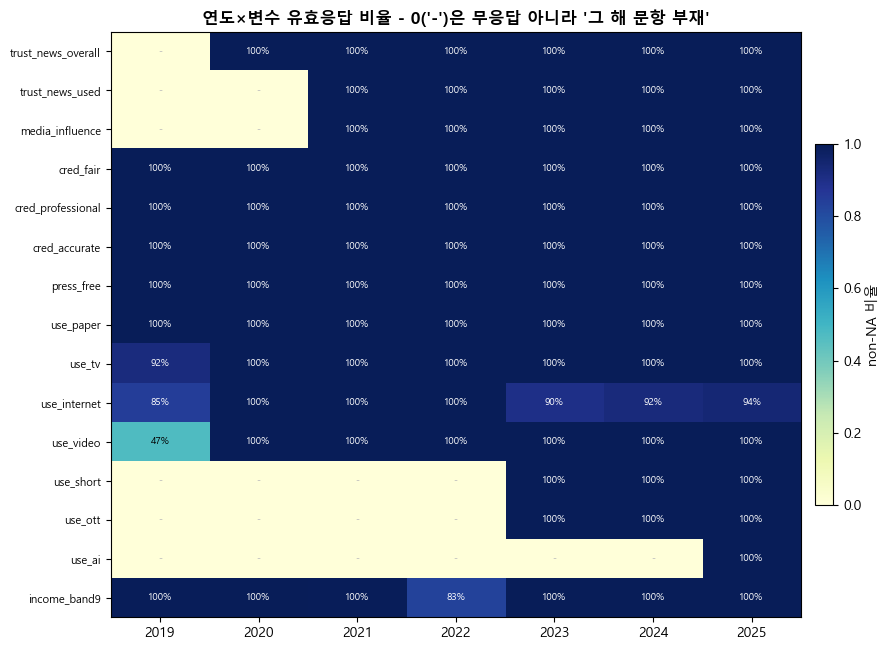

In [5]:
# [시각화 ③] 결측 = '구조적 부재' — 연도×변수 유효응답 비율
keyvars = ["trust_news_overall", "trust_news_used", "media_influence",
           "cred_fair", "cred_professional", "cred_accurate", "press_free",
           "use_paper", "use_tv", "use_internet", "use_video",
           "use_short", "use_ott", "use_ai", "income_band9"]
avail = pd.DataFrame(
    {v: [panel.loc[panel.year == y, v].notna().mean() for y in YEARS] for v in keyvars},
    index=[str(y) for y in YEARS]).T

fig, ax = plt.subplots(figsize=(9, 6.6))
im = ax.imshow(avail.values, aspect="auto", cmap="YlGnBu", vmin=0, vmax=1)
ax.set_xticks(range(len(YEARS))); ax.set_xticklabels([str(y) for y in YEARS])
ax.set_yticks(range(len(keyvars))); ax.set_yticklabels(keyvars, fontsize=8)
for i in range(len(keyvars)):
    for j in range(len(YEARS)):
        val = avail.values[i, j]
        ax.text(j, i, "-" if val == 0 else f"{val:.0%}", ha="center", va="center",
                fontsize=7, color="#bbb" if val == 0 else ("white" if val > 0.6 else "black"))
ax.set_title("연도×변수 유효응답 비율 - 0('-')은 무응답 아니라 '그 해 문항 부재'", weight="bold")
plt.colorbar(im, ax=ax, fraction=0.025, pad=0.02).set_label("non-NA 비율")
plt.tight_layout(); plt.show()

#### **[발견 ③] 결측의 절반은 무응답이 아니라 '문항 부재'다 — 비교 가능 변수를 선별해야 한다**

히트맵의 `-`(0%) 칸은 응답 거부가 아니라 **그 해 설문에 문항이 없었음**을 뜻한다. 단일문항 신뢰(`trust_news_overall`)는 2019에, `media_influence`는 2019~2020에, 신설 디지털(`use_short`·`use_ott`)은 2022 이전에, `use_ai`는 2025에만 존재한다. 반면 **credibility 핵심3(공정·전문·정확)은 7개년 전부 100%** 로 채워져 있다 — 그래서 종단 신뢰축은 단일문항이 아니라 이 배터리로 세운다. 결론: 7개년 비교는 *공통으로 존재하는 변수*(cred 핵심3·고정풀8 매체)로만 정직하게 가능하며, 부재 칸을 0으로 평균내는 순진한 처리는 거짓 추세를 만든다.

→ **③ 결측 진단 — 완료(구조적 부재 식별). 다음은 표본이 '누구'인지.**

## 4. 인구 분포 — 표본은 누구인가 (가중 전/후)

§2의 연령 편향이 어디서 오는지 **분포 수준**에서 본다. 연도별 연령 분포와, 통합 연령군 구성비를 비가중 vs `wt_year_eq` 가중으로 대비한다. 핵심은 ① 표본 중앙연령이 50대 전후로 **고령 쪽에 두텁고**, ② 가중을 적용해도 한국 인구 자체가 고령화라 고령 비중이 크게 남는다는 점(외적 타당성의 전제).

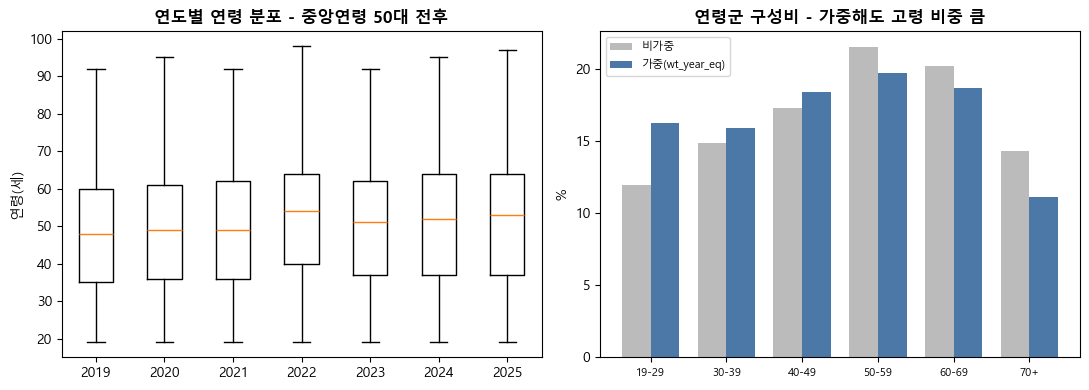

In [6]:
# [시각화 ④] 인구 분포 — 연도별 연령 + 연령군 구성비(가중 전/후)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

data = [panel.loc[panel.year == y, "age"].dropna() for y in YEARS]
axes[0].boxplot(data, tick_labels=[str(y) for y in YEARS], showfliers=False)
axes[0].set_title("연도별 연령 분포 - 중앙연령 50대 전후", weight="bold")
axes[0].set_ylabel("연령(세)")

bands = ["19-29", "30-39", "40-49", "50-59", "60-69", "70+"]
cut = pd.cut(panel["age"], [18, 29, 39, 49, 59, 69, 200], labels=bands)
unw = cut.value_counts(normalize=True).reindex(bands)
wdf = pd.DataFrame({"b": cut, "w": panel["wt_year_eq"]}).dropna(subset=["b"])
wt = wdf.groupby("b", observed=True)["w"].sum()
wt = (wt / wt.sum()).reindex(bands)
x = np.arange(len(bands)); ww = 0.38
axes[1].bar(x - ww/2, unw.values * 100, ww, label="비가중", color="#bbbbbb")
axes[1].bar(x + ww/2, wt.values * 100, ww, label="가중(wt_year_eq)", color="#4C78A8")
axes[1].set_xticks(x); axes[1].set_xticklabels(bands, fontsize=8)
axes[1].set_title("연령군 구성비 - 가중해도 고령 비중 큼", weight="bold")
axes[1].set_ylabel("%"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

#### **[발견 ④] 표본은 고령 쪽으로 두텁다 — 가중은 연도 지배를 줄이되 고령 구조는 못 지운다**

연도별 연령 분포는 모두 중앙연령 50세 전후로, 디지털 매체 과소대표의 구조적 원인이다(2022가 특히 고령이라 §2 편향을 키운다). 연령군 구성비에서 가중(`wt_year_eq`)은 연도 지배를 보정하지만, 그래도 50대+ 비중이 절반에 가깝다 — 이는 표본 결함이 아니라 **한국 인구 자체의 고령화 반영**이라 외적 타당성의 전제로 받아들인다. 따라서 다양성·디지털 해석은 항상 *가중·연령 맥락*에서 읽어야 하며, 절대수준이 아니라 **방향성**을 본다(formative 한계, 06 §결과 R4).

→ **④ 인구 분포 — 완료(고령 편중·가중 한계 확인). 다음은 두 핵심축 변수의 분포.**

## 5. 핵심변수 분포 — 신뢰(reflective)와 다양성(formative)을 어떻게 읽나

건강지수의 두 축 원변수를 **분포 수준**에서 파악한다. ① **신뢰** = credibility 핵심3(공정·전문·정확) 5점 동의 — 잠재요인을 *반영(reflective)* 하고 측정불변(노트북 21·22)이 받쳐 **연도 비교 가능**. ② **다양성** = `richness_fixed8`(7개년 공통 8매체 이용 수, 0~8) — 매체 목록이 지수를 *구성(formative)* 하므로 **절대수준 비교 금지·방향성만**. 두 축의 측정 성격이 다르다는 점이 이후 모든 해석 규칙을 가른다.

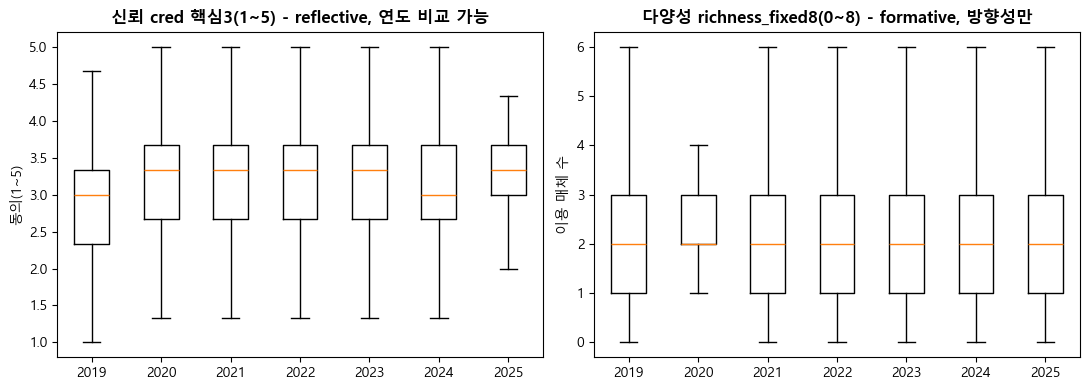

[참고] 신뢰지수(연도 비교 가능, health_index_panel) — reflective:
2019    51.3
2020    56.6
2021    58.0
2022    55.7
2023    55.2
2024    54.8
2025    60.1


In [7]:
# [시각화 ⑤] 핵심축 원변수 분포 — 신뢰(연도 비교 가능) vs 다양성(방향성만)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

cred_mean = panel[hz.CRED_FACTOR_CORE3].apply(pd.to_numeric, errors="coerce").mean(axis=1)
cdata = [cred_mean[panel.year == y].dropna() for y in YEARS]
axes[0].boxplot(cdata, tick_labels=[str(y) for y in YEARS], showfliers=False)
axes[0].set_title("신뢰 cred 핵심3(1~5) - reflective, 연도 비교 가능", weight="bold")
axes[0].set_ylabel("동의(1~5)")

ddata = [panel.loc[panel.year == y, "richness_fixed8"].dropna() for y in YEARS]
axes[1].boxplot(ddata, tick_labels=[str(y) for y in YEARS], showfliers=False)
axes[1].set_title("다양성 richness_fixed8(0~8) - formative, 방향성만", weight="bold")
axes[1].set_ylabel("이용 매체 수")
plt.tight_layout(); plt.show()

# 신뢰축만 연도 비교가 정당하므로, 패널 지수로 추세를 정량 인용(다양성은 분포만)
print("[참고] 신뢰지수(연도 비교 가능, health_index_panel) — reflective:")
print(hip.trust_index_panel(panel)["trust_index"].round(1).to_string())

> #### 🟩 Decision Box ② — 두 축의 측정 성격에 따라 해석 규칙을 분리
>
> **결정**: **신뢰축은 연도 절대수준 비교를 허용**(reflective·측정불변), **다양성축은 방향성만**(formative·고정풀 fixed8 주지표). 한 노트북에서 같은 "추세"라도 두 축에 적용하는 규칙이 다르다.
>
> **근거**: 신뢰 cred3은 공통 잠재요인을 반영해 MGCFA 측정불변이 지지된다(21·22) → "같은 자로 잰 값". 반면 richness는 매체 목록이 바뀌면 의미가 바뀌는 구성지표라, 신설 매체(숏폼·OTT·AI) 도입 시점이 추세에 혼입된다 → 고정풀 8매체로 *구성을 고정*해 방향만 본다(06 §결과 R4).
>
> **대안 기각**: 두 축을 같은 규칙으로 비교 → 다양성 절대수준의 거짓 비교(매체 추가를 행동 변화로 오인). 채택하지 않음.

#### **[발견 ⑤] 신뢰는 '같은 자로 잰 값'이라 연도를 비교하고, 다양성은 분포 모양만 본다**

cred 핵심3 분포는 7개년 모두 중앙 3점대에서 안정적이며, 측정불변이 받쳐주므로 **연도 비교가 정당**하다 — 패널 신뢰지수로 보면 2019년 51.3 저점에서 2025년 60.1 최고로 완만히 우상향한다(03에서 본격 추세 분석). 반면 richness_fixed8(0~8) 분포는 중앙 2매체 안팎으로 좁고, formative 한계상 *절대수준의 연도 비교는 하지 않고* 분포 모양·방향만 취한다. **"신뢰=연도 비교 / 다양성=방향성만"** 이라는 이 이원 규칙(DB②)이 03·21·22로 이어지는 모든 종단 해석의 토대다.

→ **⑤ 핵심변수 분포 — 완료(두 축 측정 성격 확정). 다음은 발견 종합.**

## 6. 종합 — 문제정의 → 설계 결정 매핑

이 노트북은 새 지수를 만들지 않는다. **순진한 7개년 통합이 만드는 4가지 편향을 노출**해, 다운스트림(11·20·03·21·22)이 왜 그런 처리를 *강제*하는지를 데이터로 정의했다. 아래 매핑이 본 노트북의 산출물이다.

In [8]:
# 문제정의 → 설계 결정 매핑 (이 노트북이 강제하는 후속 처리) + self-check
print("=" * 64)
print("01 데이터 파악·문제정의 — 발견 4종 -> 설계 결정")
print("=" * 64)
mapping = [
    ("① 2022 표본지배(65%)", "naive pool = 사실상 2022 조사",
     "wt_year_eq 연도균등 가중 (-> 11·20)"),
    ("② 구조적 결측", "0%는 무응답 아닌 '문항 부재'",
     "공통존재 변수(cred3·고정풀8)만 7개년 비교 (-> harmonize)"),
    ("③ 표본 고령 편중", "연령 +2.5세·디지털 -5%p 편향",
     "가중·연령 맥락 해석, RAW 신설기여 분리 (-> 03)"),
    ("④ 축 성격 상이", "신뢰=reflective / 다양성=formative",
     "신뢰만 연도 비교·다양성 방향성만 (-> 03·21·22)"),
]
for f, prob, dec in mapping:
    print(f"\n{f}")
    print(f"   문제: {prob}")
    print(f"   결정: {dec}")

# self-check (재현성 입증)
assert N == 90996, f"패널 행수 불일치: {N}"
assert abs(100 * cov[2022] / N - 64.8) < 0.5, "2022 비중 이탈"
assert int(panel["year"].nunique()) == 7, "연도 수 불일치"
print("\n" + "-" * 64)
print("[self-check] N=90,996 · 2022=64.8% · 연도 7개 — PASS")
print("⚠️ 산출 수치는 KPF 원자료 재검증 전 보고서/웹데모 직접 인용 신중(검증 게이트).")

01 데이터 파악·문제정의 — 발견 4종 -> 설계 결정

① 2022 표본지배(65%)
   문제: naive pool = 사실상 2022 조사
   결정: wt_year_eq 연도균등 가중 (-> 11·20)

② 구조적 결측
   문제: 0%는 무응답 아닌 '문항 부재'
   결정: 공통존재 변수(cred3·고정풀8)만 7개년 비교 (-> harmonize)

③ 표본 고령 편중
   문제: 연령 +2.5세·디지털 -5%p 편향
   결정: 가중·연령 맥락 해석, RAW 신설기여 분리 (-> 03)

④ 축 성격 상이
   문제: 신뢰=reflective / 다양성=formative
   결정: 신뢰만 연도 비교·다양성 방향성만 (-> 03·21·22)

----------------------------------------------------------------
[self-check] N=90,996 · 2022=64.8% · 연도 7개 — PASS
⚠️ 산출 수치는 KPF 원자료 재검증 전 보고서/웹데모 직접 인용 신중(검증 게이트).


### 종합
- **표본 구조**: 2022가 패널의 65% → 순진 통합 = 2022 편향. `wt_year_eq`로 연도 기여를 1/7 균등화(DB①).
- **순진 편향**: 보정 없이 합치면 평균연령 +2.5세 과대, 인터넷/동영상 이용 4~5%p 과소 — "2022를 7개년의 얼굴로 오인".
- **결측**: 절반은 무응답이 아닌 *문항 부재*. 7개년 비교는 공통 존재 변수(cred 핵심3·고정풀8)로만 정직.
- **인구**: 표본 고령 편중은 인구 고령화 반영(외적 타당성 전제) → 디지털·다양성은 가중·연령 맥락에서 방향성으로.
- **축 성격**: 신뢰=reflective(연도 비교 가능)·다양성=formative(방향성만) — 이원 해석 규칙(DB②)이 종단 분석의 토대.

### 한계 (v2 → 후속)
| 항목 | v2 처리 | 한계 | 후속 |
|------|--------|------|------|
| 표본 지배 | wt_year_eq 균등화 | 2022 내부 구조 자체는 불변 | 검정은 별도 보정(20 DB③) |
| 측정 동등 | reflective 가정 인용 | 본 노트북서 미검정 | MGCFA 21·22에서 입증 |
| 다양성 | formative → 방향성만 | 절대수준·연도 비교 불가 | scalar 불변 미검정 → 잠재평균 보류 |

### 다음
- **11-data-prep-harmonize**: build_year 재코딩·7개년 결합(90,996행)·`wt_year_eq` 산출 과정 입증.
- **20-eda-overview**: 본 노트북이 정의한 문제 위에서 정제된 통합 6패널·삼각검증.
- **03-health-index**: 신뢰·다양성·NCHI 7개년 추세 지수화(본 노트북의 이원 규칙 적용).

> ⚠️ 본 노트북은 **문제정의(①·P1/P2)** 다 — 산출 수치는 KPF 원자료 재검증·측정 비동등 검정 전 보고서/웹데모 직접 인용 신중(검증 게이트). 다양성·NCHI 절대수준은 formative 한계 → 방향성 위주(06 §결과 R4).